# Numerical Optimal Protocols - Stiffening Harmonic Oscillator - Various approximations

Finding optimal protocols with various approximations.

1. Set up and display sample protocols
2. Algorithms for work approximations
3. Find run time for computing the work according to each approximation
4. Finding optimal protocols and convergence time for each approximation
5. Simulating Fokker-Planck equation for a protocol
6. Compute optimal protocol for various times, record approximated work and Fokker-Planck work
7. Display results

In [90]:
import numpy as np
import matplotlib.pyplot as plt
import math
import pandas as pd
import scipy
from numba import jit, njit
from scipy.optimize import minimize

## 1. Set up and Display sample protocols

1.1. Method for computing protocol velocities, equilibrium free energy



In [91]:
# Find the velocities from a protocol

@jit(nopython=True)
def protocol_velocities(protocol, dt):
    """
    Takes protocol vector returns protocol velocities
    """

    # Find the velocities between protocol points
    velocities = np.diff(protocol)/dt

    return velocities

@jit(nopython=True)
def F_eq(k, kbT):
    # Returns equilibirum free energy for stiffness k

    beta = 1 / (kbT)
    Z = np.sqrt((2 * np.pi * kbT) / (k))  # Partition function
    F = -kbT * np.log(Z)  # Free energy

    return F

In [92]:
# Check if it's working!

protocol_ex = np.linspace(0,10,11)

print(protocol_ex)
print(protocol_velocities(protocol_ex, 0.5))

[ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10.]
[2. 2. 2. 2. 2. 2. 2. 2. 2. 2.]


1.2. Seifert optimal protocol and work

In [93]:
@jit(nopython=True)
def Analytic_protocol(k_i, k_f, tf, N):
    """
    Returns the analytic (Seifert) result for initial k_i final k_f, over time t with N steps
    """

    dts = [(tf*i)/N for i in range(N)]

    c2sta = (-1 -(k_f*tf) + np.sqrt(1 + 2*k_i*tf + k_f*k_i*tf*tf))/(2*tf + k_f*tf*tf)

    k_opt = np.zeros(N)

    for i in range(N):
        tc = (tf*i)/(N-1)
        k_opt[i] = (k_i - c2sta*(1 + c2sta*tc)) / np.power((1 + c2sta * tc), 2)

    k_opt[0] = k_i
    k_opt[N-1] = k_f

    return k_opt

@jit(nopython=True)
def Analytic_ex_work(k_i, k_f, tf):
    """
    Returns Seifert optimal work
    """

    Delta_F = F_eq(k_f, 1) - F_eq(k_i, 1)

    c2t = (-1 - k_f*tf + np.sqrt(1 + 2*k_i*tf + k_f*k_i*tf*tf))/(2 + k_f*tf)

    return (c2t*c2t)/(k_i*tf) - np.log(1 + c2t) + (k_f*(1+c2t)*(1+c2t))/(2*k_i) - 1/2 - Delta_F

1.3. Sivak-Crooks protocol and work

In [94]:
@jit(nopython=True)
def SivakCrooks_protocol(k_i, k_f, tf, N):
    """
    Returns the optimal result for initial k_i final k_f, over time t with N steps
    """

    dts = [(tf*i)/(N) for i in range(N)]

    k_opt = np.zeros(N)

    for i in range(N):
        tc = (tf*i)/(N-1)
        k_opt[i] = (k_f*k_i*np.power(tf, 2))/np.power(math.sqrt(k_i)*tc + math.sqrt(k_f)*(tf-tc),2)

    k_opt[0] = k_i
    k_opt[N-1] = k_f

    return k_opt

@jit(nopython=True)
def SivakCrooks_ex_work(k_i, k_f, tf):
    # Returns total work for SC approx

    return ((-np.sqrt(k_f) + np.sqrt(k_i))**2)/(k_f*k_i*tf)

1.4. Linear protocols for initialization

In [95]:
# Protocol to be varied, no initial and final values
@jit(nopython=True)
def Initial_linear_protocol(k_i, k_f, tf, N):
    """
    Returns a linear control parameter trajectory from k_i to k_f.

    This serves as an initial protocol to be varied. Since k_i and k_f
    are fixed, they are left out.
    """

    kstep = (k_f - k_i)/(N - 1)

    return np.array( [k_i + n*kstep for n in range(1,N-1)] )


@jit(nopython=True)
def Initial_analytic_protocol(k_i, k_f, tf, N):
    """
    Returns the analytic (Seifert) result for initial k_i final k_f, over time t with N steps
    """

    dts = [(tf*i)/N for i in range(N)]

    c2sta = (-1 -(k_f*tf) + np.sqrt(1 + 2*k_i*tf + k_f*k_i*tf*tf))/(2*tf + k_f*tf*tf)

    k_opt = np.zeros(N-2)

    for i in range(N-2):
        tc = (tf*i)/(N-1)
        k_opt[i] = (k_i - c2sta*(1 + c2sta*tc)) / np.power((1 + c2sta * tc), 2)

    return k_opt

1.5. Sample plots and work

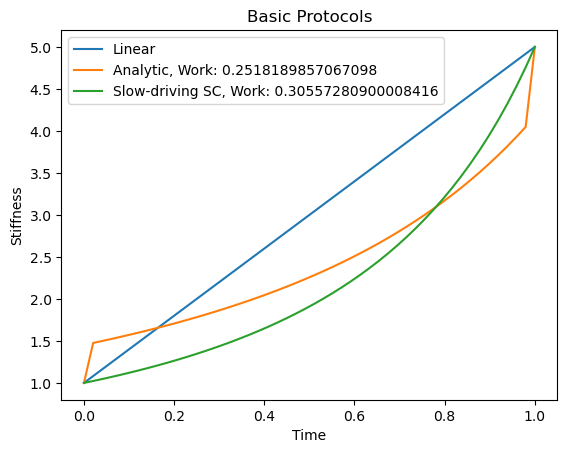

In [96]:
# Plot protocols

k_initial = 1
k_final = 5
t_total = 1
steps = 50

# Get timesteps
times = np.linspace(0, t_total, steps)

# Initialize protocol
Initial_protocol = np.zeros(steps)

# Fill with values
Initial_protocol[1:-1] = Initial_linear_protocol(k_initial, k_final, times, steps)
Initial_protocol[0] = k_initial
Initial_protocol[-1] = k_final

plt.title("Basic Protocols")

# Plot initial protocol
plt.plot(times, Initial_protocol, label = "Linear")

# Plot analytic protocol
plt.plot(times, Analytic_protocol(k_initial, k_final, t_total, steps), label = "Analytic, Work: " + str(Analytic_ex_work(k_initial, k_final, t_total)))

# Plot Sivak-Crooks protocol
plt.plot(times, SivakCrooks_protocol(k_initial, k_final, t_total, steps), label="Slow-driving SC, Work: " + str(SivakCrooks_ex_work(k_initial, k_final, t_total)))

plt.xlabel("Time")
plt.ylabel("Stiffness")
plt.legend()

plt.show()

## 2. Algorithms for work approximations

2.1. Work from linear response

In [97]:
@jit(nopython=True)
def protocol_velocities(protocol, dt):
    """
    Takes protocol vector returns protocol velocities
    """

    # Find the velocities between protocol points
    velocities = np.diff(protocol)/dt

    return velocities

@jit(nopython=True)
def work_stiff_linear_curr(protocol_var, k_i, k_f, time):
    """
    Computes work to linear order, using the current control parameter
    to compute the relaxation function.
    """

    # initialize protocol -  fix endpoints
    protocol = np.zeros(len(protocol_var) + 2)
    protocol[0] = k_i
    protocol[1:-1] = protocol_var
    protocol[-1] = k_f

    # timestep dt
    dt = time/(len(protocol) - 1)

    # get timestep and velocities over the protocol
    velocities = np.diff(protocol)/dt # protocol_velocities(protocol, dt)

    N = len(velocities)

    work = 0

    for n in range(N):

        lt = protocol[n] # current control parameter, left hand rule

        for m in range(n+1): 

            psi = (np.exp(-2*lt*dt*(n-m))/(2*lt**2))

            if m == n:
                work += (dt**2)*(1/2)*(psi)*velocities[m]*velocities[n]

            else:
                work += (dt**2)*(psi)*velocities[m]*velocities[n]

    return work

def work_stiff_linear_curr_monotonic(deltas, k_i, k_f, time):
    protocol = monotonic_protocol_from_increments(deltas, k_i, k_f)
    return work_stiff_linear_curr(protocol, time)

2.2. Work from quadratic response

In [98]:
@jit(nopython=True)
def work_stiff_quad_curr(protocol_var, k_i, k_f, time):
    """
    Computes average work over protocol while computing the velocities at the start!!!
    """
    
    protocol = np.zeros(len(protocol_var)+2)
    protocol[0] = k_i
    protocol[1:-1] = protocol_var
    protocol[-1] = k_f

    # timestep dt
    dt = time/(len(protocol) - 1)

    # get timestep and velocities over the protocol
    # velocities = protocol_velocities(protocol, dt)
    velocities = np.diff(protocol)/dt
    
    N = len(velocities)

    work = 0

    for n in range(N):
        lt = protocol[n] # current control parameter, left hand rule
        for m in range(n+1):

            psi = (np.exp(-2*lt*dt*(n-m))/(2*lt**2))

            if m == n:
                work += (dt**2)*(1/2)*(psi)*velocities[m]*velocities[n]

            else:
                work += (dt**2)*(psi)*velocities[m]*velocities[n]

            for k in range(m+1):
                
                xi = (1 + lt*dt*(m-k))*(np.exp(-2*lt*dt*max(n-m,n-k))/(2*lt**3))

                if k == m == n:
                    work += (dt**3)*(1/6)*(xi)*velocities[k]*velocities[m]*velocities[n]

                elif (k == m) or (m == n):
                    work += (dt**3)*(1/2)*(xi)*velocities[k]*velocities[m]*velocities[n]

                else:
                    work += (dt**3)*(xi)*velocities[k]*velocities[m]*velocities[n]

    return work

2.3. Linear response + weak driving

In [99]:
@jit(nopython=True)
def work_stiff_weak(protocol_var, k_i, k_f, time):
    """
    Computes work using weak approximation with initial control parameter
    to compute relaxation function.
    """

    # initialize protocol -  fix endpoints
    protocol = np.zeros(len(protocol_var) + 2)
    protocol[0] = k_i
    protocol[1:-1] = protocol_var
    protocol[-1] = k_f

    # get timestep and velocities over the protocol
    dt = time/(len(protocol) - 1)

    # velocities = protocol_velocities(protocol, dt)
    velocities = np.diff(protocol)/dt
    
    N = len(velocities)

    work = 0

    for n in range(N):

        for m in range(n+1):

            psi = (np.exp(-2*k_i*dt*(n-m))/(2*k_i**2))

            if m == n:
                work += (dt**2)*(1/2)*(psi)*abs(velocities[m])*abs(velocities[n])

            else:
                work += (dt**2)*(psi)*abs(velocities[m])*abs(velocities[n])

    return work

## 3. Find run time for computing the work according to each approximation

3.1. Run time from comparison from quadratic to linear

In [105]:
import time

# Timing for various approximations
def time_function(f, protocol, k_i, k_f, T, n=500):
    """
    Find time to compute function
    """

    start = time.time()
    for _ in range(n):
        f(protocol, k_i, k_f, T)
    return (time.time() - start) / n

N_time_trails = 1000

# unqualified linear work
time_sum = 0

for i in range(N_time_trails):

    time_sum += time_function(work_stiff_linear_curr, Initial_protocol, k_initial, k_final, t_total)

avg_time_linear = time_sum / N_time_trails

#unqualified quadratic work
time_sum = 0

for i in range(N_time_trails):

    time_sum += time_function(work_stiff_quad_curr, Initial_protocol, k_initial, k_final, t_total)

avg_time_quad = time_sum / N_time_trails

print(f"Avg time/call (linear): {avg_time_linear:.6e} seconds")
print(f"Avg time/call (quad): {avg_time_quad:.6e} seconds")
print(f"Runtime ratio (quad / linear): {avg_time_quad / avg_time_linear:.4f}")

Avg time/call (linear): 3.587913e-06 seconds
Avg time/call (quad): 6.783074e-05 seconds
Runtime ratio (quad / linear): 18.9053


## 4. Finding optimal protocols for each approximation

In [116]:
import numpy as np
from scipy.optimize import minimize
import time

k_initial = 1
k_final = 5
steps = 100
time_total = 1
print(time_total/steps)
times_to_plot = np.linspace(0, time_total, steps)

# Initialize variable points along trajectory
initial_protocol = Initial_linear_protocol(k_initial, k_final, time_total, steps)

# --- Quadratic order work (current) ---
start_quad_curr = time.time()
result_quad_curr = minimize(work_stiff_quad_curr, initial_protocol, args=(k_initial, k_final, time_total))
end_quad_curr = time.time()
print(f"Quadratic current optimization took {end_quad_curr - start_quad_curr:.4f} seconds")
print(result_quad_curr) 

result_protocol_quad_curr = list(result_quad_curr['x'])
print("Quadratic current work:", work_stiff_quad_curr(result_protocol_quad_curr, k_initial, k_final, time_total))
print(f"Quadratic current optimization took {end_quad_curr - start_quad_curr:.4f} seconds")
result_protocol_quad_curr.insert(0, k_initial)
result_protocol_quad_curr.append(k_final)

print()

# --- Linear order work (current) ---
start_linear_curr = time.time()
result_linear_curr = minimize(work_stiff_linear_curr, initial_protocol, args=(k_initial, k_final, time_total)) # we use powell in that other methods don't always converge for larger no. steps 
end_linear_curr = time.time()
print(f"Linear current optimization took {end_linear_curr - start_linear_curr:.4f} seconds")
print(result_linear_curr) 

result_protocol_linear_curr = list(result_linear_curr['x'])
print("Linear current work:", work_stiff_linear_curr(result_protocol_linear_curr, k_initial, k_final, time_total))
print(f"Linear current optimization took {end_linear_curr - start_linear_curr:.4f} seconds")
result_protocol_linear_curr.insert(0, k_initial)
result_protocol_linear_curr.append(k_final)

print()


# --- Weak / linear work ---
start_linear_weak = time.time()
result_linear_weak = minimize(work_stiff_weak, initial_protocol, args=(k_initial, k_final, time_total))
end_linear_weak = time.time()
print(f"Linear weak optimization took {end_linear_weak - start_linear_weak:.4f} seconds")
print(result_linear_weak)

result_protocol_linear_weak = list(result_linear_weak['x'])
print("Linear weak work:", work_stiff_weak(result_protocol_linear_weak, k_initial, k_final, time_total))
print(f"Linear weak optimization took {end_linear_weak - start_linear_weak:.4f} seconds")
result_protocol_linear_weak.insert(0, k_initial)
result_protocol_linear_weak.append(k_final)

# Display relationships between times
print("Ratio of quadratic to linear times: " + str((end_quad_curr - start_quad_curr)/ (end_linear_curr - start_linear_curr)))
print("Ratio of current to weak times: " + str((end_linear_curr - start_linear_curr)/ (end_linear_weak - start_linear_weak)))


0.01
Quadratic current optimization took 6.0473 seconds
  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 0.18145272145204389
        x: [ 1.121e+00  1.198e+00 ...  4.489e+00  4.696e+00]
      nit: 125
      jac: [ 8.555e-06 -4.992e-06 ... -3.260e-07 -2.831e-07]
 hess_inv: [[ 2.773e+00  2.065e+00 ...  1.558e-01  1.075e-02]
            [ 2.065e+00  4.314e+00 ... -5.570e-02 -1.929e-01]
            ...
            [ 1.558e-01 -5.570e-02 ...  1.199e+01  6.096e+00]
            [ 1.075e-02 -1.929e-01 ...  6.096e+00  4.458e+00]]
     nfev: 12573
     njev: 127
Quadratic current work: 0.18145272145204389
Quadratic current optimization took 6.0473 seconds

Linear current optimization took 0.2351 seconds
  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 0.15343243451496785
        x: [ 1.113e+00  1.185e+00 ...  4.498e+00  4.698e+00]
      nit: 138
      jac: [-5.912e-06  6.512e-06 ... -6.780e-07 -4.116e-07]
 hess_inv: 

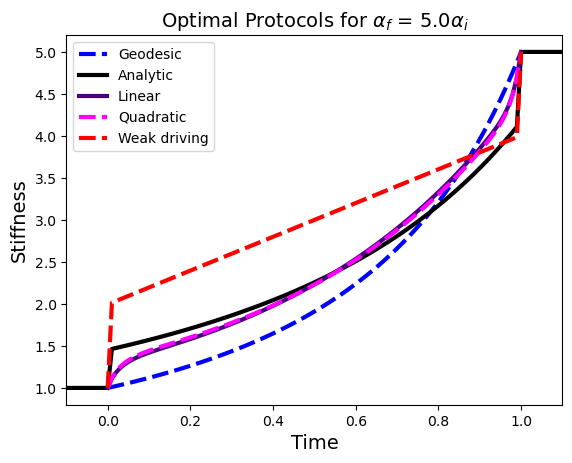

In [117]:
# plt.figure(figsize=(4,3))


plt.plot(times_to_plot, SivakCrooks_protocol(k_initial, k_final, time_total, steps), label='Geodesic', color='blue',linestyle=(0,(4,1.5)),linewidth=3)

plt.plot((-1.,) + tuple(times_to_plot) + (2.,), 
         (k_initial,) + tuple(Analytic_protocol(k_initial, k_final, time_total, steps)) + (k_final,), 
         label='Analytic', color='black', linewidth=3)

# Plot results
plt.plot(times_to_plot, result_protocol_linear_curr, label = 'Linear',color='indigo',linestyle='-',linewidth=3)
plt.plot(times_to_plot, result_protocol_quad_curr, label = 'Quadratic',color='magenta',linestyle=(0,(4,1.5)),linewidth=3)
plt.plot(times_to_plot, result_protocol_linear_weak, label = 'Weak driving',color='red',linestyle=(0,(4,1.5)),linewidth=3)

plt.xlabel('Time',fontsize=14)
plt.ylabel('Stiffness',fontsize=14)
plt.title(r'Optimal Protocols for $\alpha_f$ = ' + str(k_final/k_initial) + r'$\alpha_i$',fontsize=14)
plt.legend()

plt.xlim([-.1, 1.1])

plt.show()


## 5. Simulating Fokker-Planck equation for a protocol

5.1. Initializing setup

In [118]:
from scipy.optimize import minimize
from scipy.linalg   import expm


# define grid hyperparameters here, and potential
x_max = 5.  # 5
dx    = 0.1 # 2 # 1 # 0.1

# constructing discretized grid
x_min = -x_max
l = 1 + int((x_max - x_min) / dx) # number of discretized points
print(l, "discretization points")
xs = np.linspace(x_min, x_max, l)

# rate constant for rate matrices
k = dx**(-2)

verbose = False

101 discretization points


In [119]:
# U(x, lambda) = x**2 / 2
# lambda varying from 0 to 1

E0 = 5.

U_fixed = 0.*xs
dU_dlambda = xs**2/2


lambda_i, lambda_f = 1., 5,

# U_lambda = U_fixed + lambda*dU_dlambda


# @jit(nopython=True)
def U_from_lambda(lambda_):
    return U_fixed + lambda_*dU_dlambda

5.2. Numerically solving Fokker-Planck

In [120]:
# @jit(nopython=True)
def L_from_U(U, k):
    "make L matrix from U; k is rate constant"
    l = len(U)
    L = np.zeros((l, l))

    for j in range(l):
        i = j - 1
        if i >= 0:
            L[i, j] =  k*np.exp((U[j] - U[i])/2)
            L[j, j] -= k*np.exp((U[j] - U[i])/2)

        i = j + 1
        if i < l:
            L[i, j] =  k*np.exp((U[j] - U[i])/2)
            L[j, j] -= k*np.exp((U[j] - U[i])/2)

    # print(np.max(L))
    return L

# @jit(nopython=True) # don't know if this actually speeds things up ...
def propagate_rhos(rho_i, ts, lambdas, verbose = False):
    """
    here we propagate rho forward
    """
    # time step
    h = (ts[-1] - ts[0]) / (len(ts) - 1)

    rhos = [rho_i]

    # dlambda_guess = 0

    for n in range(len(ts) - 1):
        rho_zero = rhos[-1] # current rho
        lambda_half = lambdas[n]

        U_half = U_from_lambda(lambda_half)
        L_half = L_from_U(U_half, k)

        # expm_hL = expm_hL_from_U_h(U_half, h) # expm(h*L_half)

        expm_hL = expm(h*L_half)
        rho_one = np.dot(expm_hL, rho_zero)

        rhos.append(rho_one)

    # rhos = np.array(rhos)
    return rhos

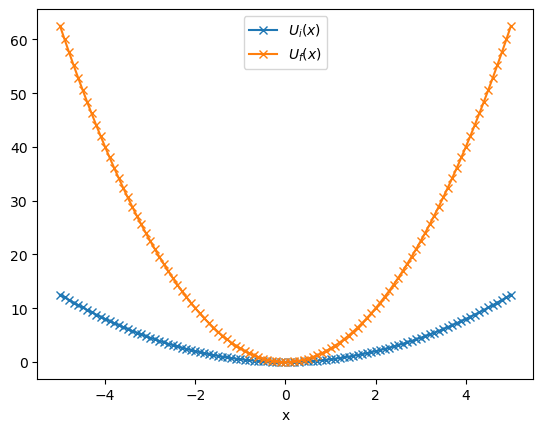

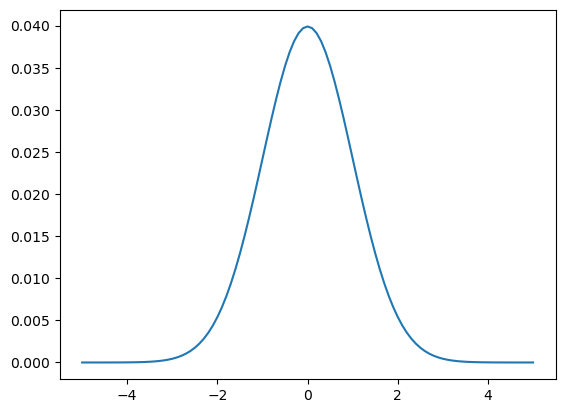

In [121]:
plt.plot(xs, U_from_lambda(lambda_i), 'x-', label = r"$U_i(x)$")
plt.plot(xs, U_from_lambda(lambda_f), 'x-', label = r"$U_f(x)$")

plt.legend()
plt.xlabel("x")
plt.show()

U_i = U_from_lambda(lambda_i)
U_f = U_from_lambda(lambda_f)

rho_i = np.exp(-U_from_lambda(lambda_i))
rho_i /= (sum(rho_i))          # normalize so sum(rho_i)*dx = 1
plt.plot(xs, rho_i, label = r"$\rho_i(x)$")

5.3. Compute work according to Fokker-Planck equation

In [122]:
def work_ex(lambdas, lambda_i, lambda_f, t_f, N):
    """
    Finds the work for a protocol lambda in time t_f, with N timesteps
    """
    # t_f = 0.2 # protocol duration

    h = t_f / N   # timestep (dt)

    # print("dx", dx, "t_f", t_f, "dt", h)

    # make time grid
    ts = np.linspace(0, t_f, N + 1)
    ts_halves = (ts[1:] + ts[:-1])/2

    U_i = U_from_lambda(lambda_i)
    U_f = U_from_lambda(lambda_f)

    # makes rho_i:
    rho_i = np.exp(-U_i)
    rho_i /= (sum(rho_i))          # normalize so sum(rho_i)*dx = 1


    # calculates free energy difference
    F_i = -np.log(sum(np.exp(-U_i)))
    F_f = -np.log(sum(np.exp(-U_f)))
    dF = F_f - F_i

    rhos = propagate_rhos(rho_i, ts, lambdas, verbose = False)

    # calculate what the excess work is via dE - Q
    Us = []
    Us.append(U_from_lambda(lambda_i))

    for lambda_ in lambdas:
        Us.append(U_from_lambda(lambda_))

    Us.append(U_from_lambda(lambda_f))

    Us = np.array(Us)

    Q = 0
    Q2= 0
    W = 0
    for i in range(N):
        U = U_from_lambda(lambdas[i])
        Q += sum(U * (rhos[i+1] - rhos[i]))
        Q2 += sum(Us[i] * (rhos[i+1] - rhos[i]))
    for i in range(N+1):
        W += sum((Us[i + 1] - Us[i]) * rhos[i])

    dE = sum(U_f*rhos[-1]) - sum(U_i*rhos[0])
    W_heat = dE - Q
    W_heat2 = dE - Q2
    print("W_heat: " + str(W_heat))
    # print("W_heat2: " + str(W_heat2))

    # print("Q: " + str(Q))
    print("W: " + str(W))

    # excess work is work minus free energy difference
    W_ex = W - dF

    print("for t_f =", t_f, "; excess work:", W_ex)

    return W_ex

5.4. Add interpolation and compute work to improve simulation

In [123]:
# Interpolate between values in the protocol to improve FP sim?

def interpolated_protocol(protocol, protocol_i, protocol_f, values):
    """
    Interpolate between values in protocol
    interpolate a new 'values' number of entries
    """
    # Create a new index array with twice the points

    total_protocol = np.insert(np.copy(protocol), 0, protocol_i)
    total_protocol = np.append(total_protocol, protocol_f)

    new_x = np.linspace(0, len(total_protocol) - 1, values * len(total_protocol) - 1)

    # Interpolate values
    interpolated = np.interp(new_x, np.arange(len(total_protocol)), total_protocol)

    return interpolated[1:-1]

def work_from_interp(protocol_var, k_i, k_f, time, interp):
    """
    Computes work from an interpolated protocol
    """

    protocol_interp = interpolated_protocol(protocol_var, k_i, k_f, interp)
    # print(len(protocol_interp))
    return work_ex(protocol_interp, k_i, k_f, time, len(protocol_interp))

5.5. Compute work for various approximations

In [124]:
def linear_optimal(k_i, k_f, time, steps, interp):
    """
    Computes FP work from linear responose
    """
    initial_protocol = Initial_linear_protocol(k_i, k_f, time, steps)
    result_linear_curr = minimize(work_stiff_linear_curr, initial_protocol, args=(k_i, k_f, time))
    result_protocol_linear_curr = list(result_linear_curr['x'])
    print("L Approx: ")
    print(work_stiff_linear_curr(result_protocol_linear_curr, k_i, k_f, time))
    return {'FP': work_from_interp(result_protocol_linear_curr, k_i, k_f, time, interp), 'Approx': work_stiff_linear_curr(result_protocol_linear_curr, k_i, k_f, time)}

def quadratic_optimal(k_i, k_f, time, steps, interp):
    """
    Computes FP work from quadratic responose
    """

    initial_protocol = Initial_linear_protocol(k_i, k_f, time, steps)
    result_quad_curr = minimize(work_stiff_quad_curr, initial_protocol, args=(k_i, k_f, time))
    result_protocol_quad_curr = list(result_quad_curr['x'])
    print("Q Approx: ")
    print(work_stiff_quad_curr(result_protocol_quad_curr, k_i, k_f, time))
    return {'FP': work_from_interp(result_protocol_quad_curr, k_i, k_f, time, interp), 'Approx': work_stiff_quad_curr(result_protocol_quad_curr, k_i, k_f, time)}

def weak_optimal(k_i, k_f, time, steps, interp):
    """
    Computes FP work from weak linear response
    """

    initial_protocol = Initial_linear_protocol(k_i, k_f, time, steps)
    result_linear_weak = minimize(work_stiff_weak, initial_protocol, args=(k_i, k_f, time))
    result_protocol_linear_weak = list(result_linear_weak['x'])
    print("WL Approx: ")
    print(work_stiff_weak(result_protocol_linear_weak, k_i, k_f, time))
    return {'FP': work_from_interp(result_protocol_linear_weak, k_i, k_f, time, interp), 'Approx': work_stiff_weak(result_protocol_linear_weak, k_i, k_f, time)}

def works_from_t_ki_kf(k_i, k_f, time, steps, interp):
    """
    Calculate work from various approximations
    """

    linear_works = linear_optimal(k_i, k_f, time, steps, interp)
    quadratic_works = quadratic_optimal(k_i, k_f, time, steps, interp)
    weak_works = weak_optimal(k_i, k_f, time, steps, interp)

    geodesic_works = {'FP': work_from_interp(SivakCrooks_protocol(k_i, k_f, time, steps)[1:-1], k_i, k_f, time, interp), 'Approx': SivakCrooks_ex_work(k_i, k_f, time)}
    analytic_works = {'FP': work_from_interp(Analytic_protocol(k_i, k_f, time, steps)[1:-1], k_i, k_f, time, interp), 'Approx': Analytic_ex_work(k_i, k_f, time)}

    return {'linear': linear_works, 'quadratic': quadratic_works, 'weak': weak_works, 'geodesic': geodesic_works, 'analytic': analytic_works}


## 6. Compute optimal protocol for various times, record approximated work and Fokker-Planck work

6.1. Run for times

In [125]:
times = np.logspace(np.log10(0.001), np.log10(100),  25)

print(times)

k_initial = 1
k_final = 5
step_val = 100
interp_val = 5

print(steps)
print(interp_val)

linear_vals_FP = []
quadratic_vals_FP = []
weak_vals_FP = []
weak_quad_vals_FP = []
geodesic_vals_FP = []
analytic_vals_FP = []

linear_vals = []
quadratic_vals = []
weak_vals = []
weak_quad_vals = []
geodesic_vals = []
analytic_vals = []

for i in range(len(times)):

  print("\nTime: " + str(times[i]))

  works_for_time = works_from_t_ki_kf(k_initial, k_final, times[i], step_val, interp_val)
  # print(works_for_time)

  linear_vals_FP.append(works_for_time['linear']['FP'])
  quadratic_vals_FP.append(works_for_time['quadratic']['FP'])
  weak_vals_FP.append(works_for_time['weak']['FP'])
  geodesic_vals_FP.append(works_for_time['geodesic']['FP'])
  analytic_vals_FP.append(works_for_time['analytic']['FP'])

  linear_vals.append(works_for_time['linear']['Approx'])
  quadratic_vals.append(works_for_time['quadratic']['Approx'])
  weak_vals.append(works_for_time['weak']['Approx'])
  geodesic_vals.append(works_for_time['geodesic']['Approx'])
  analytic_vals.append(works_for_time['analytic']['Approx'])



[1.00000000e-03 1.61559810e-03 2.61015722e-03 4.21696503e-03
 6.81292069e-03 1.10069417e-02 1.77827941e-02 2.87298483e-02
 4.64158883e-02 7.49894209e-02 1.21152766e-01 1.95734178e-01
 3.16227766e-01 5.10896977e-01 8.25404185e-01 1.33352143e+00
 2.15443469e+00 3.48070059e+00 5.62341325e+00 9.08517576e+00
 1.46779927e+01 2.37137371e+01 3.83118685e+01 6.18965819e+01
 1.00000000e+02]
100
5

Time: 0.001
L Approx: 
0.41019175213803394
W_heat: 1.9972468108920414
W: 1.9972468108920411
for t_f = 0.001 ; excess work: 1.1925282916503712
Q Approx: 
0.5349114203273179
W_heat: 1.99721691834558
W: 1.9972169183455812
for t_f = 0.001 ; excess work: 1.1924983991039113
WL Approx: 
3.9961092784699552
W_heat: 1.996062614270859
W: 1.9960626142708597
for t_f = 0.001 ; excess work: 1.1913440950291898
W_heat: 1.9976915566707878
W: 1.9976915566707887
for t_f = 0.001 ; excess work: 1.1929730374291188
W_heat: 1.995993455161769
W: 1.9959934551617695
for t_f = 0.001 ; excess work: 1.1912749359200996

Time: 0.001615

## 7. Display results

7.1. Approximated work

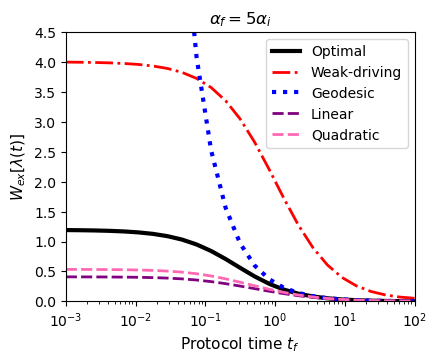

In [126]:
plt.figure(figsize=(4.5,3.5))

plt.plot(times, analytic_vals, label="Optimal",color='black',lw=3)
plt.plot(times, weak_vals, label='Weak-driving',color='red',linestyle='-.',lw=2)
plt.plot(times, geodesic_vals, label='Geodesic',color='blue',linestyle=':',lw=3)
plt.plot(times, linear_vals, label='Linear', color='purple',linestyle=(0,(4,1.5)),lw=2)
plt.plot(times, quadratic_vals, label='Quadratic', color='#FF69B4',linestyle=(0,(4,1.5)),lw=2)

# plt.plot(new_times, new_linears, 'ro')

# plt.xlim(1,2.5)
plt.ylim(0,4.5)
plt.xlim(times[0], times[-1])

# plt.yscale('log')
plt.xscale('log')

plt.xlabel('Protocol time ' + r'$t_f$', fontsize=11)
plt.ylabel(r'$W_{ex}[\lambda(t)]$', fontsize=11)

plt.title(r'$\alpha_f=5\alpha_i$')

plt.legend()
plt.show()

7.2. Fokker-Planck work

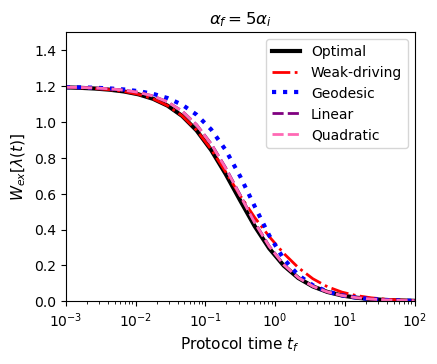

In [127]:
plt.figure(figsize=(4.5,3.5))

plt.plot(times, analytic_vals_FP, label="Optimal",color='black',lw=3)
plt.plot(times, weak_vals_FP, label='Weak-driving',color='red',linestyle='-.',lw=2)
plt.plot(times, geodesic_vals_FP, label='Geodesic',color='blue',linestyle=':',lw=3)
plt.plot(times, linear_vals_FP, label='Linear', color='purple',linestyle=(0,(4,1.5)),lw=2)
plt.plot(times, quadratic_vals_FP, label='Quadratic', color='#FF69B4',linestyle=(0,(4,1.5)),lw=2)

# plt.plot(new_times, new_linears, 'ro')

# plt.xlim(1,2.5)
# plt.ylim(0.1,0.4)
plt.ylim(0,1.5)
plt.xlim(times[0], times[-1])


# plt.yscale('log')
plt.xscale('log')

plt.xlabel('Protocol time ' + r'$t_f$', fontsize=11)
plt.ylabel(r'$W_{ex}[\lambda(t)]$', fontsize=11)

plt.title(r'$\alpha_f=5\alpha_i$')

plt.legend()
plt.show()

7.3. Deviation

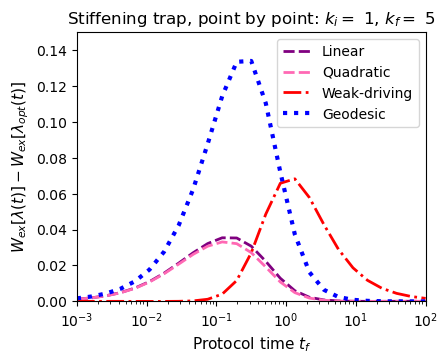

In [128]:
plt.figure(figsize=(4.5,3.5))

plt.title(r'Stiffening trap, point by point: $k_i =$ ' + str(k_initial) + r', $k_f =$ ' + str(k_final))

# plt.plot(times, np.subtract(analytic_vals, analytic_vals), label="Optimal",color='black',lw=3)
plt.plot(times, np.subtract(linear_vals_FP, analytic_vals_FP), label='Linear',color='purple',linestyle=(0,(4,1.5)),lw=2)
plt.plot(times, np.subtract(quadratic_vals_FP, analytic_vals_FP), label='Quadratic',color='#FF69B4',linestyle=(0,(4,1.5)),lw=2)
plt.plot(times, np.subtract(weak_vals_FP, analytic_vals_FP), label='Weak-driving',color='red',linestyle='-.',lw=2)
plt.plot(times, np.subtract(geodesic_vals_FP, analytic_vals_FP), label='Geodesic',color='blue',linestyle=':',lw=3)

# plt.plot(new_times, np.subtract(new_linears, new_analytics))

# plt.yscale('log')
plt.xscale('log')

# plt.xlim(0.00025,400)
plt.xlim(times[0], times[-1])
plt.ylim(0, .15)

plt.xlabel('Protocol time ' + r'$t_f$',fontsize=11)
plt.ylabel(r'$W_{ex}[\lambda(t)] - W_{ex}[\lambda_{opt}(t)]$',fontsize=11)

plt.legend()
plt.show()

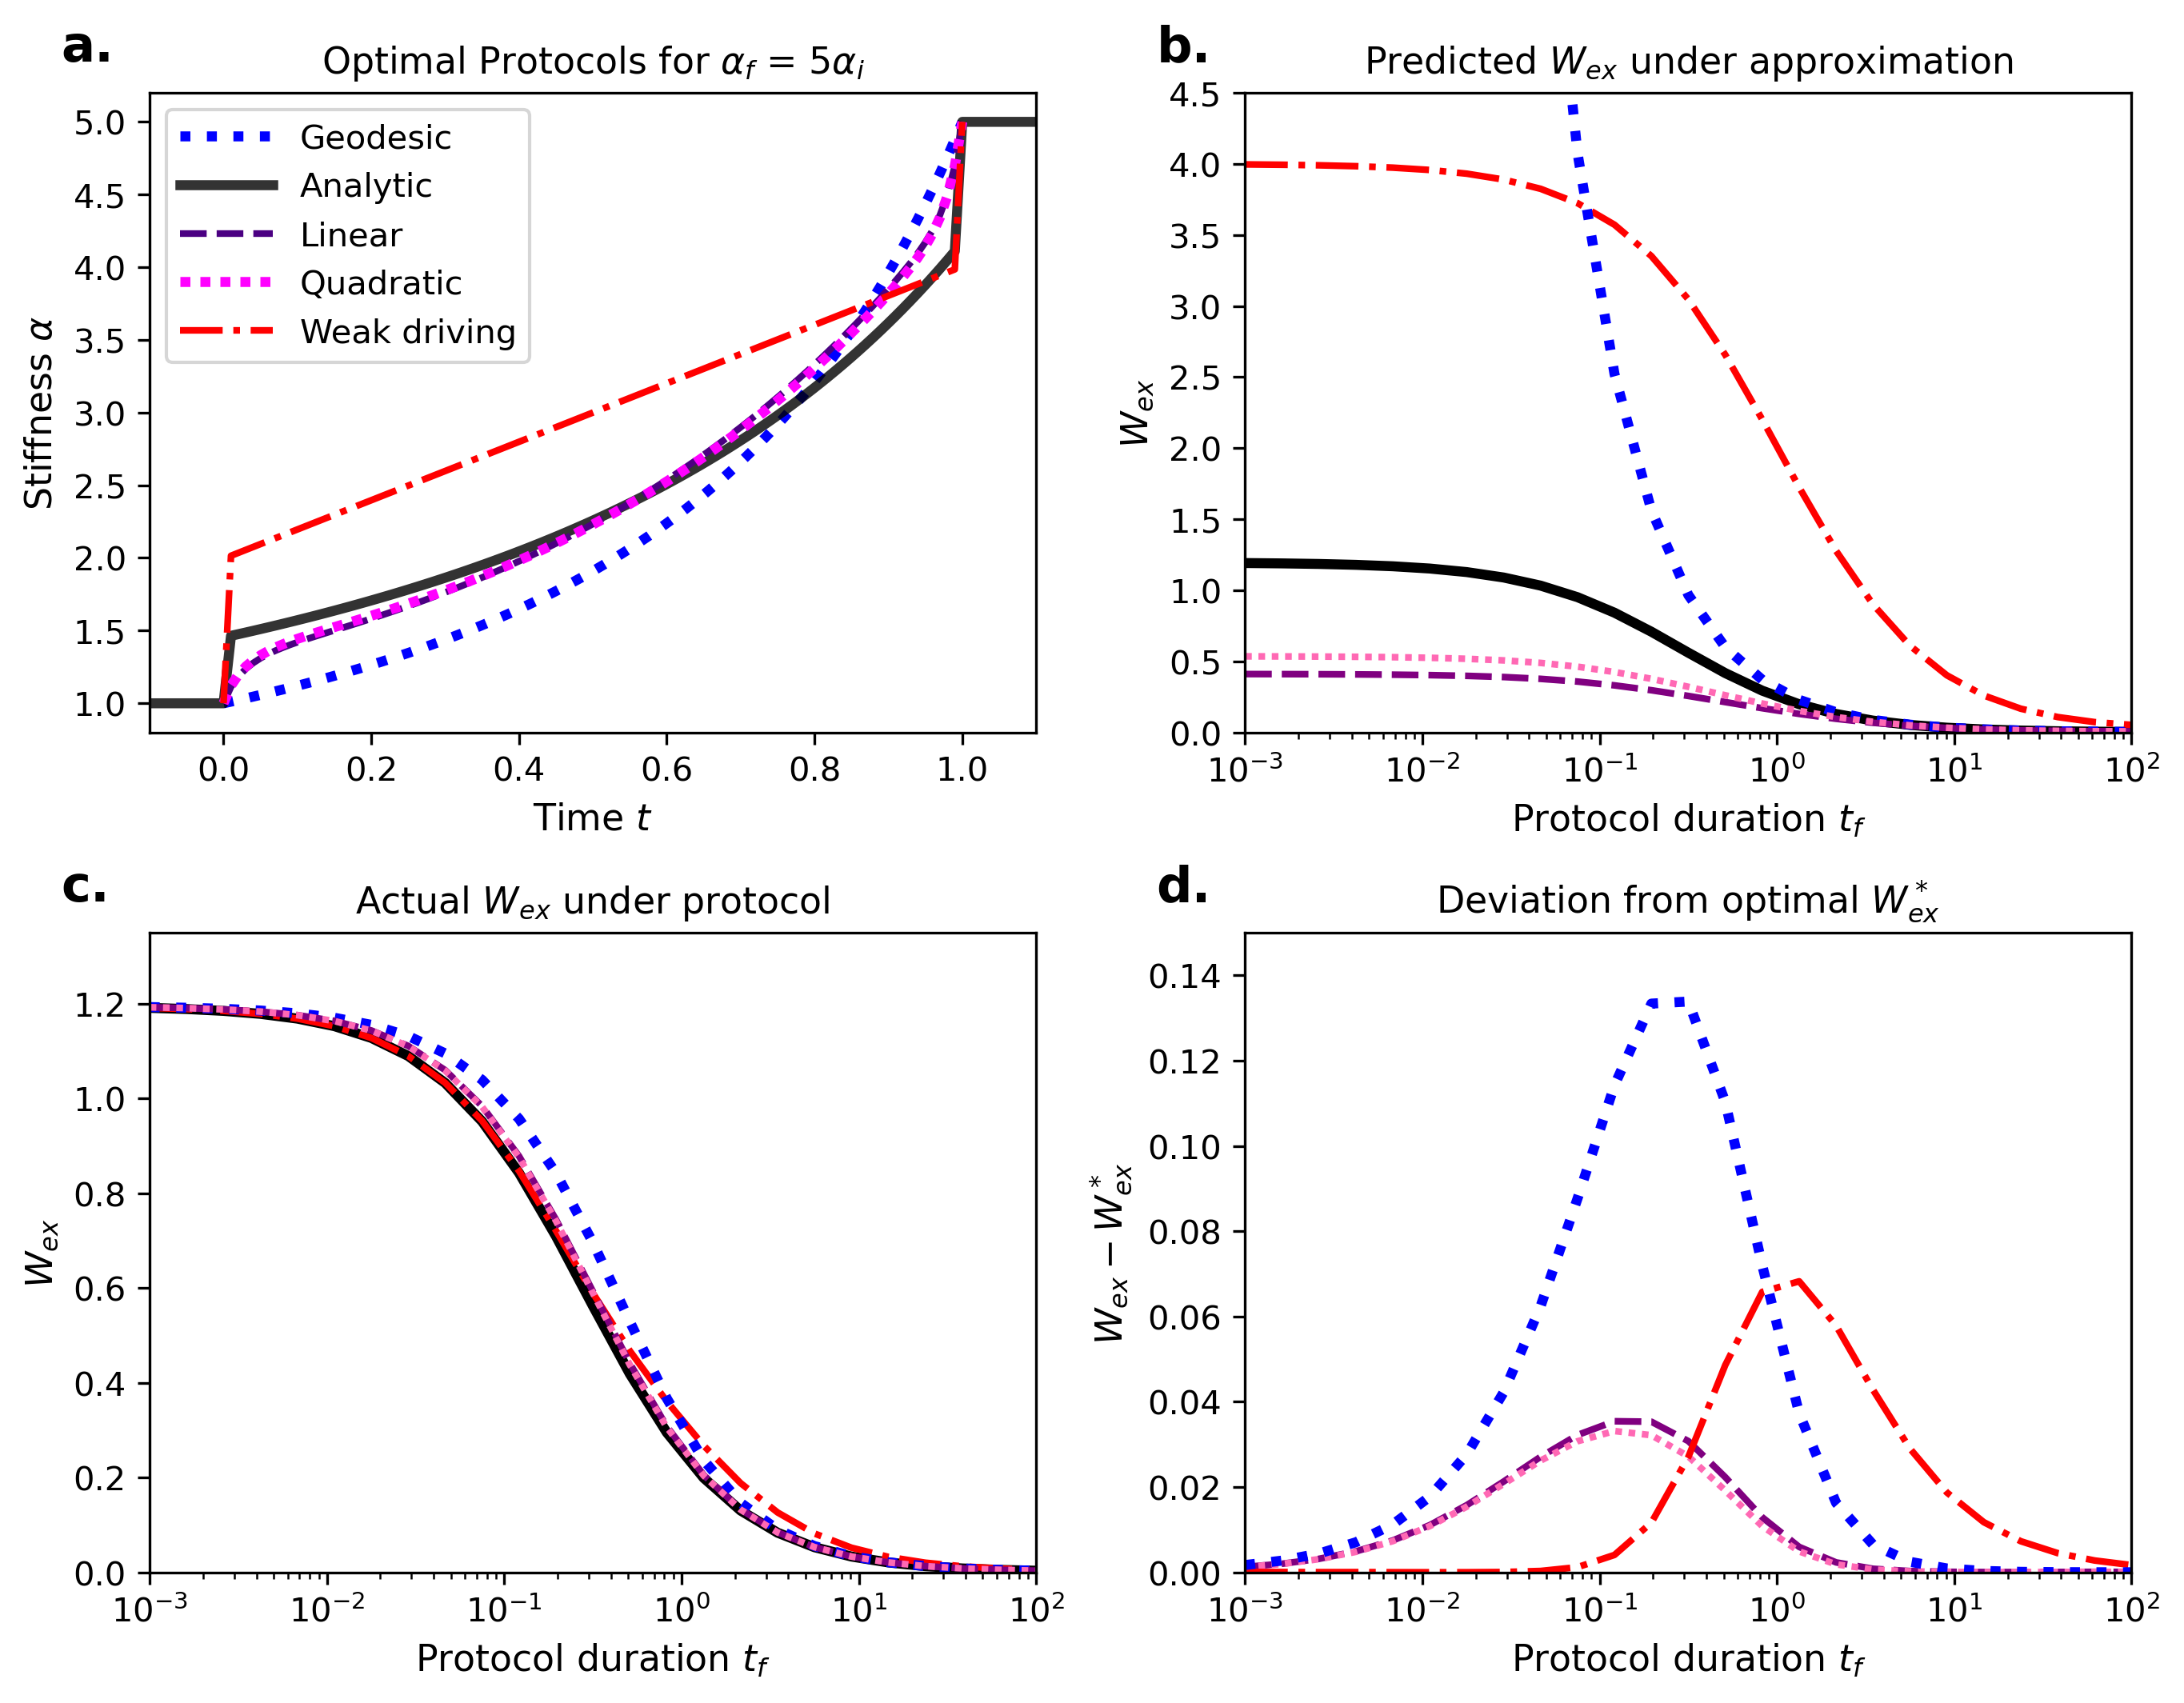

In [130]:
# plt.figure(figsize=(4,3))


fig, axs = plt.subplots(2, 2, figsize=(9,7), layout='constrained', dpi = 300)
((ax1, ax2), (ax3, ax4)) = axs




ax1.plot(times_to_plot, SivakCrooks_protocol(k_initial, k_final, time_total, steps), label='Geodesic', color='blue',linestyle=':',linewidth=3)

ax1.plot((-1.,) + tuple(times_to_plot) + (2.,), 
         (k_initial,) + tuple(Analytic_protocol(k_initial, k_final, time_total, steps)) + (k_final,), 
         label='Analytic', color='black', linewidth=3, alpha = 0.8)

# Plot results
ax1.plot(times_to_plot, result_protocol_linear_curr, label = 'Linear',color='indigo',linestyle=(0,(4,1.5)),linewidth=2)
ax1.plot(times_to_plot, result_protocol_quad_curr, label = 'Quadratic',color='magenta',linestyle=(0,(1,1)),linewidth=3)
ax1.plot(times_to_plot, result_protocol_linear_weak, label = 'Weak driving',color='red',linestyle='-.',linewidth=2)






ax1.set_xlabel('Time ' + r'$t$',fontsize=11)
ax1.set_ylabel('Stiffness ' + r'$\alpha$',fontsize=11)
ax1.set_title(r'Optimal Protocols for $\alpha_f$ = ' + str(int(k_final/k_initial)) + r'$\alpha_i$',fontsize=11)

ax1.set_xlim([-.1, 1.1])


# ax1.legend()







ax2.plot(times, analytic_vals, label="Optimal",color='black',lw=3)
ax2.plot(times, weak_vals, label='Weak-driving',color='red',linestyle='-.',lw=2)
ax2.plot(times, geodesic_vals, label='Geodesic',color='blue',linestyle=':',lw=3)
ax2.plot(times, linear_vals, label='Linear', color='purple',linestyle=(0,(4,1.5)),lw=2)
ax2.plot(times, quadratic_vals, label='Quadratic', color='#FF69B4',linestyle=(0,(1,1)),lw=2)

# plt.plot(new_times, new_linears, 'ro')

# plt.xlim(1,2.5)
ax2.set_ylim(0,4.5)
ax2.set_xlim(times[0], times[-1])

# plt.yscale('log')
ax2.set_xscale('log')
ax2.set_xlabel('Protocol duration ' + r'$t_f$', fontsize=11)
ax2.set_ylabel(r'$W_{ex}$', fontsize=11)
ax2.set_title(r'Predicted $W_{ex}$ under approximation',fontsize=11)

# ax2.set_title(r'$\alpha_f=5\alpha_i$')













ax3.plot(times, analytic_vals_FP, label="Optimal",color='black',lw=3)
ax3.plot(times, weak_vals_FP, label='Weak-driving',color='red',linestyle='-.',lw=2)
ax3.plot(times, geodesic_vals_FP, label='Geodesic',color='blue',linestyle=':',lw=3)
ax3.plot(times, linear_vals_FP, label='Linear', color='purple',linestyle=(0,(4,1.5)),lw=2)
ax3.plot(times, quadratic_vals_FP, label='Quadratic', color='#FF69B4',linestyle=(0,(1,1)),lw=2)

# plt.plot(new_times, new_linears, 'ro')

# plt.xlim(1,2.5)
# plt.ylim(0.1,0.4)
ax3.set_ylim(0,1.35)
ax3.set_xlim(times[0], times[-1])


# plt.yscale('log')
ax3.set_xscale('log')

ax3.set_xlabel('Protocol duration ' + r'$t_f$', fontsize=11)
ax3.set_ylabel(r'$W_{ex}$', fontsize=11)

ax3.set_title(r'Actual $W_{ex}$ under protocol',fontsize=11)

# ax3.set_title(r'$\alpha_f=5\alpha_i$')









# ax4.set_title(r'Stiffening trap, point by point: $k_i =$ ' + str(k_initial) + r', $k_f =$ ' + str(k_final))

# plt.plot(times, np.subtract(analytic_vals, analytic_vals), label="Optimal",color='black',lw=3)
ax4.plot(times, np.subtract(linear_vals_FP, analytic_vals_FP), label='Linear',color='purple',linestyle=(0,(4,1.5)),lw=2)
ax4.plot(times, np.subtract(quadratic_vals_FP, analytic_vals_FP), label='Quadratic',color='#FF69B4',linestyle=(0,(1,1)),lw=2)
ax4.plot(times, np.subtract(weak_vals_FP, analytic_vals_FP), label='Weak-driving',color='red',linestyle='-.',lw=2)
ax4.plot(times, np.subtract(geodesic_vals_FP, analytic_vals_FP), label='Geodesic',color='blue',linestyle=':',lw=3)

# plt.plot(new_times, np.subtract(new_linears, new_analytics))

# plt.yscale('log')
ax4.set_xscale('log')

# plt.xlim(0.00025,400)
ax4.set_xlim(times[0], times[-1])
ax4.set_ylim(0, .15)

ax4.set_xlabel('Protocol duration ' + r'$t_f$',fontsize=11)
ax4.set_ylabel(r'$W_{ex} - W_{ex}^*$',fontsize=11)
ax4.set_title(r'Deviation from optimal $W_{ex}^*$ ',fontsize=11)




# plt.tight_layout()
ax1.legend(handlelength=2.8)


import string
axs = axs.flat


fig.set_constrained_layout_pads(w_pad=0.05, h_pad=0.05, wspace=0, hspace=0)

for n, ax in enumerate(axs):
    
    ax.text(-0.1, 1.05, string.ascii_lowercase[n] + ".", transform=ax.transAxes, 
            size=15, weight='bold')
    

plt.savefig("approx_plots_together_v1.pdf")
plt.show()